In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.bandit_task import BanditTaskNeuroPixelsDataset
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.cognitive_graphs.cognitive_graphs import behavioral_state_diagram, cluster_neural_activity
from sklearn.ensemble import RandomForestClassifier
from ncmcm.statistical_testing.markov import *
from IPython.display import HTML
import os

In [3]:
os.getcwd()
os.chdir('..')

## Load Bandit Task Data

We load Neuropixels recordings from rat medial prefrontal cortex (mPFC) during a two-arm bandit task. The behavioral states include:
- Intertrial
- Hold
- Choosing left
- Choosing right
- Reward
- No reward

Dataset cached to: datasets/raw/twoArmBandit/JPAS_0023_20230922/BanditTaskNeuroPixelsDataset/fs20_gaussian_all_normminmax_global_4829c969.pkl
Loaded BanditTaskNeuroPixelsDataset from datasets/raw/twoArmBandit/JPAS_0023_20230922
Neuronal data shape: (575, 25863), Behavioral data shape: (1, 25863), Sampling frequency: 19.999288481238988 Hz
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choosing right'}
Neuronal data shape: (575, 25863)
Behavioral data shape: (25863,)
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choosing right'}
Recording length: 21.55 minutes
Sampling frequency: 19.999288481238988 Hz


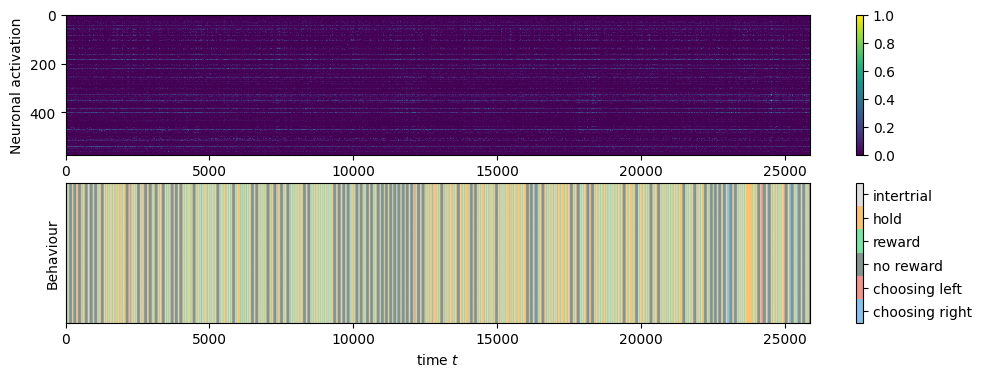

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [15]:
# Load bandit task data
data_path = 'datasets/raw/twoArmBandit/JPAS_0023_20230922'

dataset = BanditTaskNeuroPixelsDataset(
    data_path=data_path,
    downsample_fs=20,  # Downsample to 20 Hz
    downsample_method='gaussian',  # Gaussian smoothing
    good_neurons_only=False,  # Include all neurons
    normalize_method='minmax_global'  # Min-max normalization across all neurons
)

# Extract neuronal and behavioral data
x = dataset.x.toarray()  # Convert sparse to dense (time, neurons)
b = dataset.b.toarray().flatten()  # Convert sparse to dense and flatten to 1D
behaviors = list(dataset.b_labels_dict.values())

print(f"Neuronal data shape: {x.shape}")
print(f"Behavioral data shape: {b.shape}")
print(f"Behavioral labels: {dataset.b_labels_dict}")
print(f"Recording length: {dataset.get_recording_length_mins():.2f} minutes")
print(f"Sampling frequency: {dataset.fs} Hz")

# Plot neuronal and behavioral data overview
plotting_neuronal_behavioural(
    x.T,  # Transpose to (neurons, time)
    b=b,
    b_names=dataset.b_labels_dict,
    b_colors=dataset.get_color_map_for_plotting()
)

## Test if behavioral sequence follows Markov property

In [17]:
p, _ = markov_property_test(b, simulations=250)
print(f"Markov property test p-value: {p:.4f}")
p

Markov property test p-value: 0.0000


np.float64(0.0)

## Check if behavior is decodable from neuronal activity

Before clustering, we test how well we can predict behavioral states directly from the neuronal traces. This gives us a baseline measure of how much information about behavior is encoded in the neural activity.

In [16]:
from ncmcm.cognitive_graphs.calculations import fit_model
from sklearn.linear_model import LogisticRegression

# Fit a model to predict behavior from neural activity
yp_map, pred_model, cv_scores = fit_model(
    neuron_traces=x,
    B=b.astype(int),
    base_model=LogisticRegression(max_iter=1000),
    ensemble=True,
    cv_folds=5  # 5-fold cross-validation
)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Mean cross-validation results for 5 folds:
	Mean: 0.595989221505141

Accuracy for full training data: 0.649963267989019

Cross-validation scores: [0.54900445 0.54765127 0.62207616 0.64752514 0.6136891 ]
Mean CV accuracy: 0.5960 ± 0.0405


## Cognitive state sequence by clustering behavioral probability trajectories (BPT)

This method `cluster_neural_activity` allows for a lot of customizability, with only the first 3 parameters being required.
For the model parameter, each classifier with the methods: predict, predict_proba and fit works fine.

We cluster the neural activity to find cognitive states that:
- Follow the Markov property
- Follow the stationary property
- Can predict behavioral states from neural activity

Accuracy for full training data: 0.9894443800023199
Testing markovianity for 6 clusters - repetition 1
Testing markovianity for 6 clusters - repetition 2
Testing markovianity for 6 clusters - repetition 3
Testing markovianity for 6 clusters - repetition 4
Testing markovianity for 6 clusters - repetition 5
(5, 1)


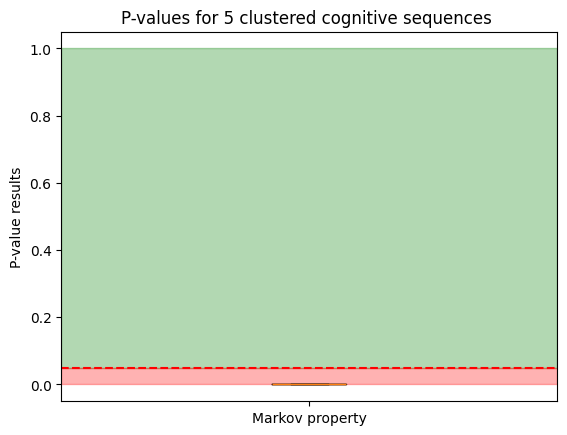

In [13]:
cognitive_states = cluster_neural_activity(
    N=x,  # Transpose to (neurons, time)
    B=b.astype(int),
    n_clusters=6,
    nrep=5,
    ensemble=True,
    sim_m=100,
    sim_s='optimal',
    chunks=3,
    clustering='kmeans',
    kmeans_init='auto',
    test_mode='both',
    test_stationary_property=False,
    model=RandomForestClassifier(n_estimators=20, random_state=42),
    plot=True
)

The plot above shows the distributions of the p-values of the statistical tests for each of the simulated cognitive state sequences.

The method sorts the cognitive state sequence simulations according to the 'best' p-values.
Entries with p-values signaling no violations against the Markov property are listed first.

#### Each tuple in the list contains: 
- the sequence
- p-value markov property
- p-value stationary property ks-test (optional)
- p-value stationary property t-test (optional)

In [12]:
cognitive_states

[(array([2, 2, 2, ..., 1, 1, 1], shape=(25863,), dtype=int32),
  np.float64(0.0),
  np.float64(1.0352158050647012e-36),
  np.float64(2.8051275038828935e-44)),
 (array([2, 2, 2, ..., 0, 0, 0], shape=(25863,), dtype=int32),
  np.float64(0.0),
  np.float64(5.328387434220759e-35),
  np.float64(1.6716803969891738e-41)),
 (array([2, 2, 2, ..., 0, 0, 0], shape=(25863,), dtype=int32),
  np.float64(0.0),
  np.float64(2.5041004150165568e-34),
  np.float64(1.6484427992772995e-37)),
 (array([2, 2, 2, ..., 0, 0, 0], shape=(25863,), dtype=int32),
  np.float64(0.0),
  np.float64(1.1157246171733706e-32),
  np.float64(4.963470945706698e-38)),
 (array([2, 2, 2, ..., 1, 1, 1], shape=(25863,), dtype=int32),
  np.float64(0.0),
  np.float64(8.017135240615738e-30),
  np.float64(4.971146750768041e-32)),
 (array([0, 0, 0, ..., 1, 1, 1], shape=(25863,), dtype=int32),
  np.float64(0.0),
  np.float64(2.688537120044914e-28),
  np.float64(9.872363932929473e-34)),
 (array([0, 0, 0, ..., 2, 2, 2], shape=(25863,), dty

In [11]:
best_result = cognitive_states[0]
best_sequence = best_result[0]
best_result

(array([2, 2, 2, ..., 1, 1, 1], shape=(25863,), dtype=int32),
 np.float64(0.0),
 np.float64(1.0352158050647012e-36),
 np.float64(2.8051275038828935e-44))

### Making Sense of the Output

The plot shows us the results of the tests, which see if there is sufficient evidence against one of the two properties. The p-value results for all repetitions of cognitive sequence clusterings are plotted, with values in the green signaling sequences that seem not to disrespect the properties according to the test. 

The result for the sequence with the most promising result (cognitive state sequence) is printed above. The Markov property and the stationary property p-values indicate whether evidence was found that disrespects these properties. The cognitive sequence could therefore be stemming from a Markov process 1st order if both p-values are > 0.05.

## Plot the cognitive graph

Now after we have found a fitting cognitive state sequence, that seems not to violate any of the properties of a Markov Process, we can create a cognitive graph. First we plot the diagram with all edges by setting threshold to 0. Using the `weight_hist` parameter we see the distribution in edge thickness which can help us decide setting a threshold of minimal edge thickness for the cognitive graph.

In [ ]:
result = behavioral_state_diagram(
    best_sequence, 
    b, 
    behaviors=behaviors,
    weights_hist=True,
    bins=15,
    threshold=0
)

In [ ]:
behavioral_state_diagram(
    best_sequence, 
    b,
    behaviors=behaviors,
    threshold=0.002,
    figsize=(8, 8)
)

behavioral_state_diagram(
    best_sequence, 
    b,
    behaviors=behaviors,
    offset=5,
    figsize=(8, 8)
)

Using these insights we can either let the algorithm decide where to put the cut-off or decide our self. We can also define an offset, this will change the spacing between clusters.

In [ ]:
# Next we also plot the adjacency matrix
behavioral_state_diagram(
    best_sequence, 
    b,
    behaviors=behaviors,
    adj_matrix=True,
    figsize=(15, 10)
)

## Interactive plots (using pyvis)

For the interactive graph we set a filename where we want to save the HTML-file and we can also set an option parameter. This is set with a predefined physics script [options = 0, 1 or 2] or a custom script with a path to the JSON-file. The default value for options is 0, giving a graph with forces pushing nodes apart and pulling edges together.

In [ ]:
behavioral_state_diagram(
    best_sequence, 
    b,
    behaviors=behaviors,
    interactive='figures/Interactive_graph_bandit',
    options=0
)

behavioral_state_diagram(
    best_sequence, 
    b,
    behaviors=behaviors,
    interactive='figures/Interactive_graph_bandit_no_physics',
    options='ncmcm/cognitive_graphs/json_physics/custom_physics.json'
)

## Statistical tests demonstration

To demonstrate the effectiveness of the statistical tests, implemented and used to generate the best cognitive graphs according to the NCMCM-framework, we simulate 3 different sequences and test them.

In [ ]:
# Simulate some sequences
seq_1, _ = simulate_markov_sequence(M=3000, N=5, order=1)
seq_2, _ = simulate_markov_sequence(M=3000, N=5, order=2)
seq_non_stat_3 = non_stationary_process(M=3000, N=5, changes=5)
seq_non_stat_4 = non_stationary_process2(M=3000, N=5, changes=5, epsilon=0.05)

The `markov_property_test` returns the empirical 1st order transition matrix and a p-value.
A p-value below 0.05 signals behavior that seems to violate the memoryless property (aka. Markov property) of a 1st order Markov process.

In [ ]:
p_1, P_1 = markov_property_test(seq_1, simulations=250)
p_2, P_2 = markov_property_test(seq_2, simulations=250)
print(f'Since {round(p_1, 3)} > 0.05, the sequence 1 could come from a 1st order Markov process.')
print(f'Since {round(p_2, 3)} < 0.05, the sequence 2 seems not to come from a 1st order Markov process.')

The `stationary_property_test` returns the p-value for a KS- and/or T- test.
A p-value below 0.05 signals that the sequence violates the stationary property of a Markov process.

In [ ]:
p_ks_test_1, _, p_t_test_1, _ = stationary_property_test(
    seq_1, 
    chunks_num=5, 
    simulations='optimal', 
    test_mode='both'
)

p_ks_test_2, ks_statistic_2, p_t_test_2, t_statistic_2 = stationary_property_test(
    seq_non_stat_3, 
    chunks_num=5, 
    simulations='optimal',  
    test_mode='both'
)

p_ks_test_3, ks_statistic_3, p_t_test_3, t_statistic_3 = stationary_property_test(
    seq_non_stat_4, 
    chunks_num=5, 
    simulations='optimal',  
    test_mode='both'
)

print(f'Since {round(p_ks_test_1, 3)} > 0.05 and {round(p_t_test_1, 3)} > 0.05, the sequence 1 could come from a stationary Markov process')
print(f'Since {round(p_ks_test_2, 3)} < 0.05 and {round(p_t_test_2, 3)} < 0.05, the sequence 3 seems not to come from a stationary Markov process')
print(f'Since {round(p_ks_test_3, 3)} < 0.05 and {round(p_t_test_3, 3)} < 0.05, the sequence 4 seems not to come from a stationary Markov process')

It is important to note here, that the `stationary_property_test` gets very sensitive with big sample sizes. Which means long sequences in combination with many simulations can lead to significant results more easily. This is because the KS-test and the t-test, which are employed in this method, struggle with very different sample sizes, as large samples can overshadow smaller ones and make subtle differences appear statistically significant. Consequently, careful interpretation is needed, as results may not always reflect meaningful differences but rather the influence of sample size disparities. This can be somewhat mitigated by setting a lower value for `chunks_num`. It increases one sample size linearly while the second sample size increases exponentially, potentially skewing the comparison.